**Task: Using this sample dataset, create or optimize data preprocessing pipeline using opencv and pytorch and include image mask technique in the pipeline and save the output.**

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


Found 1750 images under: /content/drive/MyDrive/COCO2017_SAMPLE/train2017
Dataset size: 1750. Example item shapes:
image tensor: torch.Size([3, 256, 256]) mask tensor: torch.Size([1, 256, 256])
Saved 8 processed images and masks to /content/drive/MyDrive/COCO2017_SAMPLE/processed_output


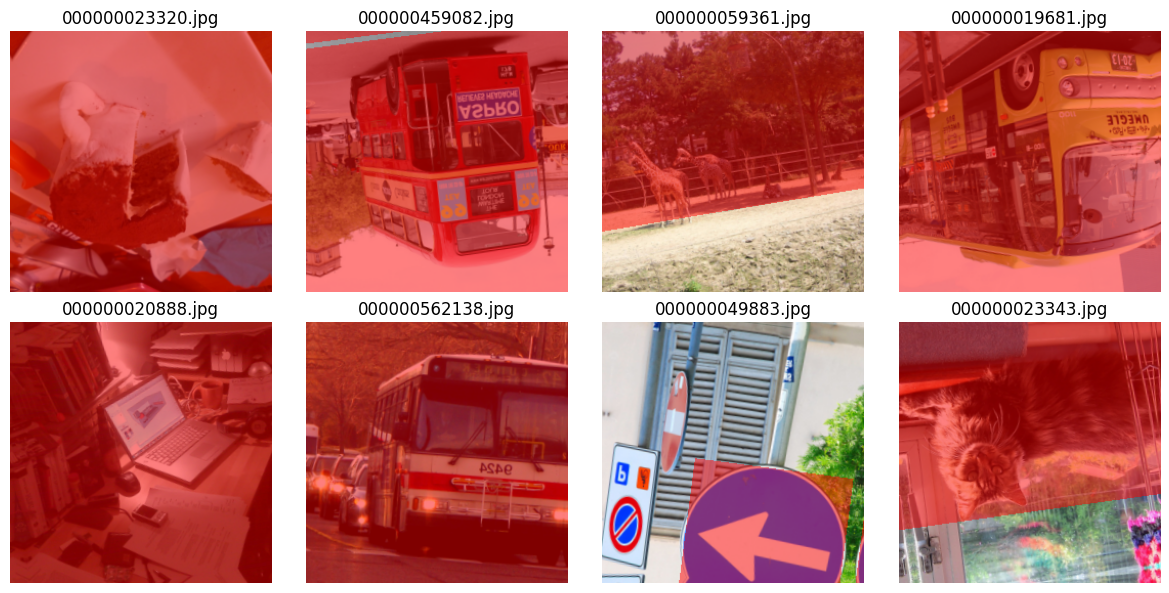

In [3]:
# Complete pipeline: load images, create placeholder masks, apply consistent transforms,
# create Dataset/DataLoader, visualize and save processed outputs.
#
# Paste this into your notebook and run. Change `data_path` to your images folder.

import os
from glob import glob
import random
import math
import numpy as np
from PIL import Image
import cv2
from pathlib import Path
import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF

# ---------------------------
# CONFIG
# ---------------------------
# Update this path to your image folder. If you are using Colab and mounted Drive,
# set it to the folder that contains your images, e.g.:
# data_path = "/content/drive/MyDrive/AI_Vision_Extract_Nov25/data (1)/train2017"
data_path = "/content/drive/MyDrive/COCO2017_SAMPLE/train2017"

# output dir for processed images
output_dir = "/content/drive/MyDrive/COCO2017_SAMPLE/processed_output"
os.makedirs(output_dir, exist_ok=True)

# image size used for transforms
IMG_SIZE = 256

# number of random samples to visualize/save
NUM_SAMPLES_TO_SHOW = 8

# random seed for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


# ---------------------------
# Utilities: list images
# ---------------------------
def list_images(folder, exts=(".jpg", ".jpeg", ".png")):
    folder = Path(folder)
    imgs = []
    if not folder.exists():
        return imgs
    for ext in exts:
        imgs.extend(sorted(map(str, folder.rglob(f"*{ext}"))))
    return imgs

image_list = list_images(data_path)
print(f"Found {len(image_list)} images under: {data_path}")

if len(image_list) == 0:
    # fallback: try current directory for images
    image_list = list_images(".")
    print(f"Fallback - found {len(image_list)} images in current directory.")


# ---------------------------
# Placeholder mask generation
# ---------------------------
def make_placeholder_mask(image_np, mode="filled_bbox"):
    """
    Generate a synthetic mask for demonstration:
    - 'filled_bbox' : fill bounding box of largest contour after thresholding
    - 'center_circle': circle at center
    - 'random_blobs' : few random blobs
    """
    h, w = image_np.shape[:2]
    gray = cv2.cvtColor(image_np, cv2.COLOR_RGB2GRAY)
    _, thr = cv2.threshold(gray, 0, 255, cv2.THRESH_OTSU + cv2.THRESH_BINARY_INV)

    if mode == "filled_bbox":
        # find contours and pick the largest
        contours, _ = cv2.findContours(thr, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        mask = np.zeros((h, w), dtype=np.uint8)
        if len(contours) == 0:
            # fallback to center rectangle
            cx, cy = w//2, h//2
            rw, rh = int(w*0.4), int(h*0.4)
            mask[cy-rh//2:cy+rh//2, cx-rw//2:cx+rw//2] = 255
        else:
            largest = max(contours, key=cv2.contourArea)
            x,y,ww,hh = cv2.boundingRect(largest)
            cv2.rectangle(mask, (x,y), (x+ww, y+hh), 255, -1)
        return mask
    elif mode == "center_circle":
        mask = np.zeros((h, w), dtype=np.uint8)
        cv2.circle(mask, (w//2, h//2), min(h,w)//4, 255, -1)
        return mask
    elif mode == "random_blobs":
        mask = np.zeros((h, w), dtype=np.uint8)
        num_blobs = random.randint(1,4)
        for _ in range(num_blobs):
            rx = random.randint(0, w-1)
            ry = random.randint(0, h-1)
            rr = random.randint(min(h,w)//12, min(h,w)//6)
            cv2.circle(mask, (rx, ry), rr, 255, -1)
        # optionally do a bit of blur
        mask = cv2.GaussianBlur(mask, (11,11), 0)
        _, mask = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)
        return mask
    else:
        # default to all zeros
        return np.zeros((h, w), dtype=np.uint8)


# ---------------------------
# Transform function (image + mask consistently)
# ---------------------------
def random_flip(image, mask):
    if random.random() > 0.5:
        image = np.fliplr(image).copy()
        mask = np.fliplr(mask).copy()
    if random.random() > 0.5:
        image = np.flipud(image).copy()
        mask = np.flipud(mask).copy()
    return image, mask

def random_rotation(image, mask, max_deg=15):
    angle = random.uniform(-max_deg, max_deg)
    h, w = image.shape[:2]
    M = cv2.getRotationMatrix2D((w/2,h/2), angle, 1.0)
    image_r = cv2.warpAffine(image, M, (w,h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT_101)
    mask_r = cv2.warpAffine(mask, M, (w,h), flags=cv2.INTER_NEAREST, borderMode=cv2.BORDER_REFLECT_101)
    return image_r, mask_r

def center_crop_resize(image, mask, size=IMG_SIZE):
    # convert numpy to PIL for consistent resize with antialiasing
    img_p = Image.fromarray(image)
    mask_p = Image.fromarray(mask)
    # center crop to square then resize
    short = min(img_p.size)
    left = (img_p.width - short)//2
    top = (img_p.height - short)//2
    img_c = img_p.crop((left, top, left+short, top+short)).resize((size, size), Image.BILINEAR)
    mask_c = mask_p.crop((left, top, left+short, top+short)).resize((size, size), Image.NEAREST)
    return np.array(img_c), np.array(mask_c)

def normalize_image(image_np):
    # image as uint8 HWC, convert to float32 and normalize to [0,1], then standardize
    img = image_np.astype(np.float32) / 255.0
    mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
    std  = np.array([0.229, 0.224, 0.225], dtype=np.float32)
    img = (img - mean) / std
    return img

# ---------------------------
# Dataset
# ---------------------------
class ImageMaskDataset(Dataset):
    def __init__(self, image_paths, mask_mode="filled_bbox", transforms=True):
        self.image_paths = image_paths
        self.mask_mode = mask_mode
        self.transforms = transforms

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        p = self.image_paths[idx]
        img = cv2.imread(p, cv2.IMREAD_COLOR)
        if img is None:
            # handle unreadable image
            raise RuntimeError(f"Can't read image {p}")
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # create placeholder mask
        mask = make_placeholder_mask(img, mode=self.mask_mode)

        # crop/resize to square and desired size
        img, mask = center_crop_resize(img, mask, size=IMG_SIZE)

        # apply random augmentations (image and mask together)
        if self.transforms:
            img, mask = random_flip(img, mask)
            img, mask = random_rotation(img, mask, max_deg=10)

        # normalize image (float32)
        img_norm = normalize_image(img)          # HWC float32
        mask_bin = (mask > 127).astype(np.uint8) # 0/1 HWC or HW

        # convert to torch tensors: image as C x H x W, mask as 1 x H x W
        img_tensor = torch.from_numpy(img_norm.transpose(2,0,1)).float()
        mask_tensor = torch.from_numpy(mask_bin).unsqueeze(0).float()

        return {
            "image": img_tensor,
            "mask": mask_tensor,
            "meta": {
                "path": p,
                "orig_size": img.shape[:2]
            }
        }

# ---------------------------
# Create dataset and dataloader
# ---------------------------
# shuffle and pick subset if too many images
random.shuffle(image_list)
if len(image_list) > 2000:
    image_list = image_list[:2000]

dataset = ImageMaskDataset(image_list, mask_mode="filled_bbox", transforms=True)
dataloader = DataLoader(dataset, batch_size=4, shuffle=True, num_workers=0)

print(f"Dataset size: {len(dataset)}. Example item shapes:")
if len(dataset) > 0:
    ex = dataset[0]
    print("image tensor:", ex["image"].shape, "mask tensor:", ex["mask"].shape)


# ---------------------------
# Visualize a few samples and save processed outputs
# ---------------------------
def denormalize(img_tensor):
    # img_tensor is C x H x W
    mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
    std  = np.array([0.229, 0.224, 0.225], dtype=np.float32)
    img = img_tensor.numpy().transpose(1,2,0)
    img = img * std + mean
    img = np.clip(img, 0, 1)
    img = (img * 255).astype(np.uint8)
    return img

# show and save up to NUM_SAMPLES_TO_SHOW images
num_to_show = min(NUM_SAMPLES_TO_SHOW, len(dataset))
indices = list(range(len(dataset)))
random.shuffle(indices)
indices = indices[:num_to_show]

plt.figure(figsize=(12, 3 * math.ceil(num_to_show / 4)))
for i, idx in enumerate(indices):
    sample = dataset[idx]
    img_t = sample["image"]
    mask_t = sample["mask"]
    img_np = denormalize(img_t)
    mask_np = (mask_t.squeeze(0).numpy() * 255).astype(np.uint8)

    # overlay mask on image for visualization (red overlay)
    overlay = img_np.copy()
    color = np.array([255, 0, 0], dtype=np.uint8)
    overlay[mask_np > 127] = (overlay[mask_np > 127] * 0.5 + color * 0.5).astype(np.uint8)

    ax = plt.subplot(math.ceil(num_to_show / 4), 4, i+1)
    ax.imshow(overlay)
    ax.axis("off")
    ax.set_title(Path(sample["meta"]["path"]).name)

    # save processed image and mask
    out_img_path = os.path.join(output_dir, f"processed_image_{i+1}.jpg")
    out_mask_path = os.path.join(output_dir, f"processed_mask_{i+1}.png")
    cv2.imwrite(out_img_path, cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR))
    cv2.imwrite(out_mask_path, mask_np)

plt.tight_layout()
#plt.show()

print(f"Saved {num_to_show} processed images and masks to {os.path.abspath(output_dir)}")
